# Setting up a simple example using an articulated robot

In [ ]:
import sys
from pathlib import Path


# Define paths
REPO_ROOT = Path.cwd().parent               # Repo root (ikp-sbl)
LECTURE_EXAMPLES = REPO_ROOT / "lecture_examples"

# Add BOTH to sys.path
for path in [str(REPO_ROOT), str(LECTURE_EXAMPLES)]:
    if path not in sys.path:
        sys.path.insert(0, path)

from lecture_examples.IPPlanarManipulator import PlanarJoint, PlanarRobot
from lecture_examples.IPEnvironmentKin import KinChainCollisionChecker, planarRobotVisualize, animateSolution
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon, LineString
from shapely import plotting

from planners.SBL import SBL
from modules import IPVISsbl

obst = dict()
obst["obs1"] = LineString([(-2, 0), (-0.8, 0)]).buffer(0.5)
obst["obs2"] = LineString([(2, 0), (2, 1)]).buffer(0.2)
obst["obs3"] = LineString([(-1, 2), (1, 2)]).buffer(0.1)

# 2-DoF

In [2]:
r = PlanarRobot(n_joints=2)
environment = KinChainCollisionChecker(r, obst,fk_resolution=.2)

Draw start and goal position of robot within the environment

In [3]:
start_joint_pos = [2.0, 0.5]
end_joint_pos = [-2.0, -0.5]

start = start_joint_pos
goal  = end_joint_pos

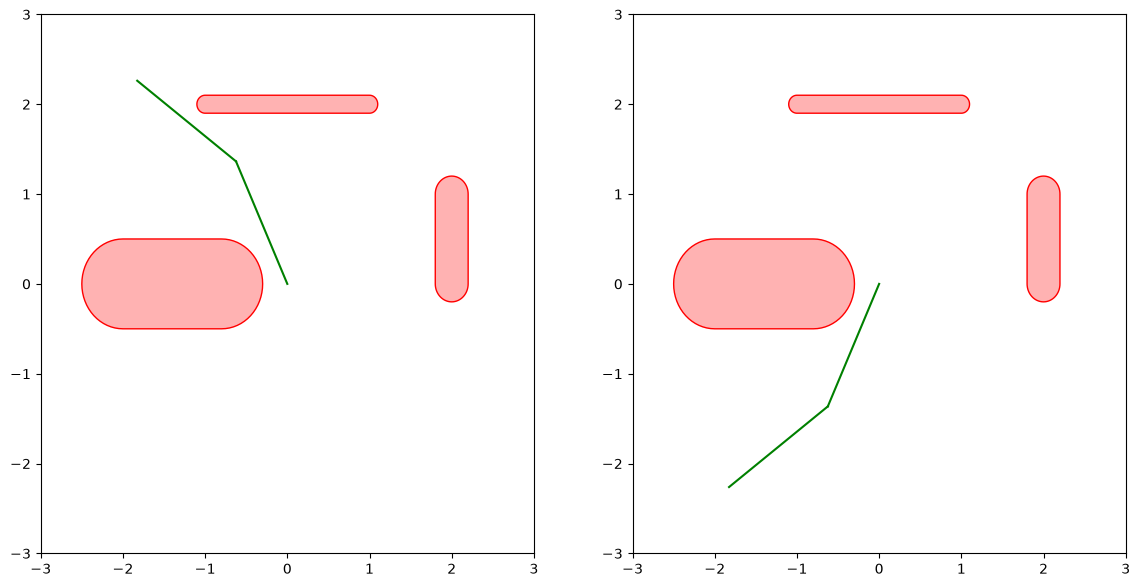

In [4]:
fig_local = plt.figure(figsize=(14, 7))
## left figure for robot start position
ax1 = fig_local.add_subplot(1, 2, 1)
ax1.set_xlim([-3,3])
ax1.set_ylim([-3,3])
environment.drawObstacles(ax1, True)
r.move(start)
planarRobotVisualize(r, ax1)
## right figure robot goal position
ax2 = fig_local.add_subplot(1, 2, 2)
ax2.set_xlim([-3,3])
ax2.set_ylim([-3,3])
environment.drawObstacles(ax2, True)
r.move(goal)
planarRobotVisualize(r, ax2)

In [5]:
config = {} #SBL.DEFAULT_CONFIG.copy()
config["iterations"] = 1000
config["eta"] = 2.0

planner = SBL(environment)


In [6]:
## plan path from start to goal
solution = planner.planPath(start, goal, config)
print(solution)

[Node(start, [2.  0.5]), Node(start, [1.86530862 0.74892767]), Node(start, [1.98873994 1.09476871]), Node(start, [1.49274801 1.51456278]), Node(start, [-1.32067036  2.84093573]), Node(goal, [-2.25665481  1.75225407]), Node(goal, [-2.22786449  0.34010001]), Node(goal, [-2.  -0.5])]


In [7]:
animateSolution(planner, environment, solution, IPVISsbl.sblVisualize)

# 4-DoF

In [8]:
r = PlanarRobot(n_joints=4)
limits = [[-3.14,3.14],[-3.14,3.14],[-3.14,3.14],[-3.14,3.14]]
environment = KinChainCollisionChecker(r, obst, limits=limits, fk_resolution=.2)
planner = SBL(environment)

In [9]:
start_joint_pos = [2.0, 0.5, 0.5, 0.5]
end_joint_pos = [-2.0, -0.5, -0.5, -0.5]
start = [start_joint_pos]
goal  = [end_joint_pos]

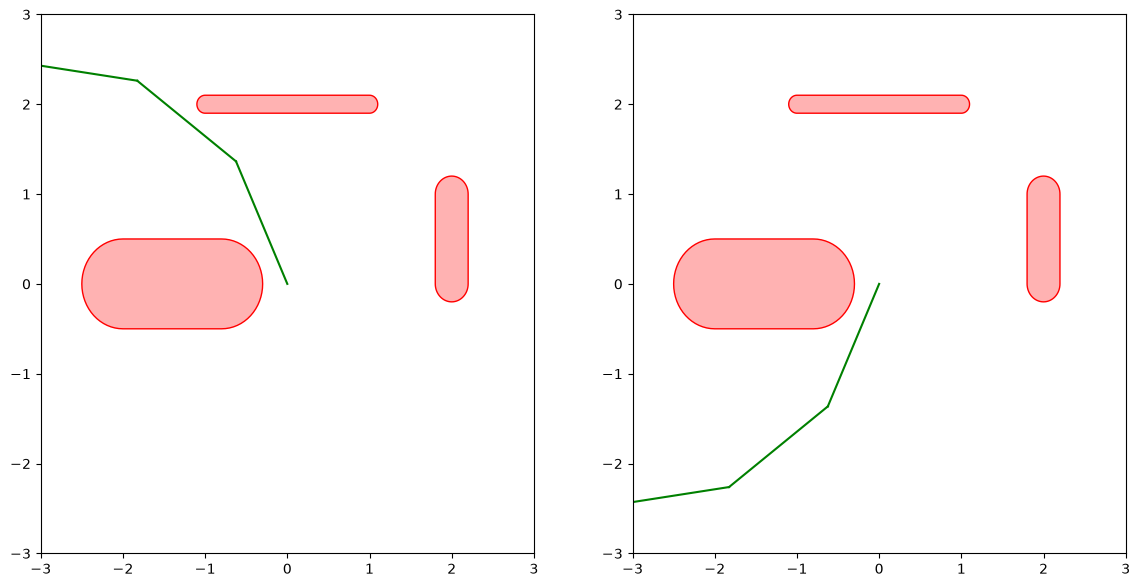

In [10]:
fig_local = plt.figure(figsize=(14, 7))
## left figure for robot start position
ax1 = fig_local.add_subplot(1, 2, 1)
ax1.set_xlim([-3,3])
ax1.set_ylim([-3,3])
environment.drawObstacles(ax1, True)
r.move(start_joint_pos)
planarRobotVisualize(r, ax1)
## right figure robot goal position
ax2 = fig_local.add_subplot(1, 2, 2)
ax2.set_xlim([-3,3])
ax2.set_ylim([-3,3])
environment.drawObstacles(ax2, True)
r.move(end_joint_pos)
planarRobotVisualize(r, ax2)

In [11]:
solution = planner.planPath(start, goal, config)
print(solution)

[Node(start, [2.  0.5 0.5 0.5]), Node(start, [ 1.67837672  1.5465409  -0.44299954  0.90256985]), Node(start, [ 1.45639481  2.03408279 -0.10784853  0.49858873]), Node(start, [0.71654169 2.08035401 0.39843244 0.56305505]), Node(start, [0.53787937 2.04217941 0.4387342  0.55062541]), Node(start, [0.44849308 2.0193571  0.45541638 0.55061673]), Node(start, [0.54677294 1.9318156  0.77976937 0.66122505]), Node(start, [-0.65607056  1.881536    1.11729312  1.16505635]), Node(start, [-0.58370821  2.0420813   1.13440814  1.17755989]), Node(start, [-0.96689054  2.29276955  0.26650686  1.53811645]), Node(start, [-1.27691312  2.36131913  0.30537349  1.98489883]), Node(start, [-0.32412875  2.48935486  0.47762445  2.59599805]), Node(start, [-0.61850142  2.38998775  0.6717658   2.81115979]), Node(goal, [-1.52659234  2.9632426   0.61917254  3.61529661]), Node(goal, [-2.19792094  1.65450823  2.42309769  2.70294453]), Node(goal, [-1.78790441  0.83845671  2.20431872  1.5332941 ]), Node(goal, [-1.56107203  0

In [ ]:
animateSolution(planner, environment, solution, IPVISsbl.sblVisualize)

## 6-DoF

In [ ]:
r = PlanarRobot(n_joints=6)
limits = [[-3.14,3.14],[-3.14,3.14],[-3.14,3.14],[-3.14,3.14],[-3.14,3.14],[-3.14,3.14]]
environment = KinChainCollisionChecker(r, obst, limits=limits, fk_resolution=.2)
planner = SBL(environment)

In [ ]:
start_joint_pos = [2.0, 0.5, 0.5, 0.5, 0.5, 0.5]
end_joint_pos = [-2.0, -0.5, -0.5, -0.5, -0.5, -0.5]
start = [start_joint_pos]
goal  = [end_joint_pos]

In [ ]:
fig_local = plt.figure(figsize=(14, 7))
## left figure for robot start position
ax1 = fig_local.add_subplot(1, 2, 1)
ax1.set_xlim([-3,3])
ax1.set_ylim([-3,3])
environment.drawObstacles(ax1, True)
r.move(start_joint_pos)
planarRobotVisualize(r, ax1)
## right figure robot goal position
ax2 = fig_local.add_subplot(1, 2, 2)
ax2.set_xlim([-3,3])
ax2.set_ylim([-3,3])
environment.drawObstacles(ax2, True)
r.move(end_joint_pos)
planarRobotVisualize(r, ax2)

In [ ]:
solution = planner.planPath(start, goal, config)
print(solution)

In [ ]:
animateSolution(planner, environment, solution, IPVISsbl.sblVisualize)